# Temporal difference

## TD(0)

### Random walk 

In [ ]:
# TD(0) algorithm
# Random walk
# T1 <- A <-> B <-> C <-> D <-> E -> T2
using Plots
using Random
rng = Xoshiro(99)


function td0_random_walk(alpha = 0.05, viz = false)
    # Policy: random next state. 
    # true state values
    v = [1/6, 2/6, 3/6, 4/6, 5/6]
    err = []
    V_array = []

    # Init step
    # Reward
    R = Dict("T1" => 0, "A" => 0, "B" => 0, "C" => 0, "D" => 0, "E" => 0, "T2" => 1); 
    # Estimated value function
    V = Dict("A" => 0.5, "B" => 0.5, "C" => 0.5, "D" => 0.5, "E" => 0.5, "T1" => 0, "T2" => 0)  
    
    gamma = 1

    # Build graph
    Grp = Dict("A" => ["T1","B"], "B" => ["A","C"], "C" => ["B","D"], "D" => ["C","E"], "E" => ["D","T2"])

    for episode = 1:100 
        # init state 
        S = "C"
        while S != "T1" && S != "T2"
            # print(S,"->")
            # action: take probability of next step
            Snext = rand(rng, Grp[S])
            # check reward of next state
            reward = R[Snext]
            # update: V
            V[S] = V[S] + alpha*(reward + gamma * V[Snext] - V[S])
            # update: S to next state 
            S = Snext

        end
        # print(S)
        # println()
        # print(V)
        # println()
        push!(err, RMSE([V["A"], V["B"], V["C"], V["D"], V["E"]], v))

        # saves animation plot points
        if viz == true
            push!(V_array, [V["A"], V["B"], V["C"], V["D"], V["E"]])
        end

    end

    if viz == true
        # animation plot
        anim = @animate for i ∈ 1:length(V_array)
            plot(["A", "B", "C", "D", "E"], [v V_array[i]], 
            marker = 2, label = ["True values, v" "Estimated values, V(s)"], 
            xlabel="State", ylabel="Estimated value, v", ylims = (0,1),
            title = "Episode: $i")
        end
        gif(anim, "td0_random_walk.gif")
    end

    return err
end

td0_random_walk (generic function with 3 methods)

In [ ]:
# Root mean square error
function RMSE(estimate, truth)
    s = 0
    for i = 1:length(truth)
        s += (truth[i] - estimate[i])^2
    end
    return sqrt(1/length(truth)*s)
end

RMSE (generic function with 1 method)

In [2]:
# Generates gif animation
td0_random_walk(0.05, true);

LoadError: UndefVarError: td0_random_walk not defined

In [ ]:
err0 = td0_random_walk(0.05);
err1 = td0_random_walk(0.1);
err2 = td0_random_walk(0.15);

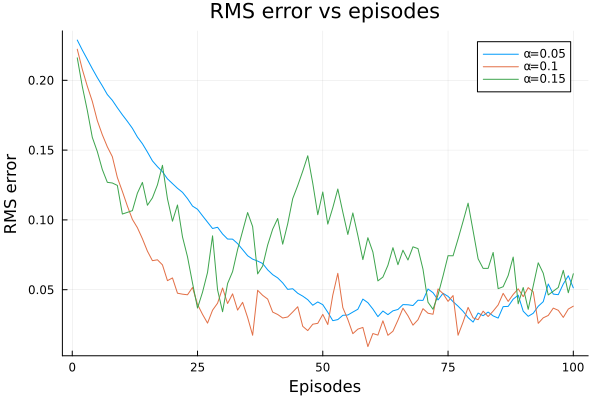

In [ ]:
plot([err0 err1 err2], title = "RMS error vs episodes", label=["\\alpha=0.05" "\\alpha=0.1" "\\alpha=0.15"], xlabel = "Episodes", ylabel = "RMS error")

## Sarsa: On-policy TD Control

### Windy grid world

In [1]:
using Random, Distributions, Plots
Random.seed!(123)

alpha = 0.5
gamma = 1
max_row = 7   # max grid rows
max_col = 10  # max grid columns
start = (4,1) # start position
goal = (4,8)  # goal position
# set all positions to -1 reward except goal 
reward = -1 * ones(max_row, max_col)  
reward[goal...] = 0 # set goal reward to 0
reward


7×10 Matrix{Float64}:
 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0   0.0  -1.0  -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0

Min steps found: 17


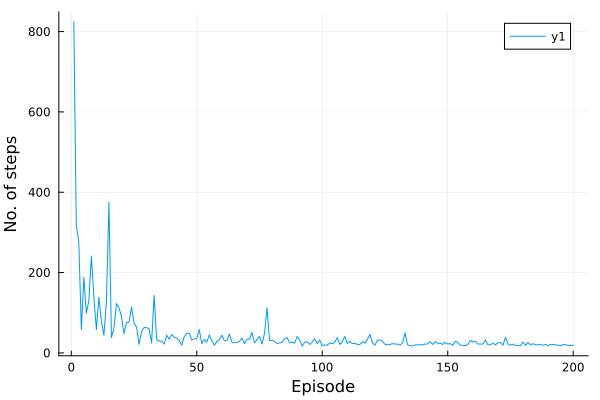

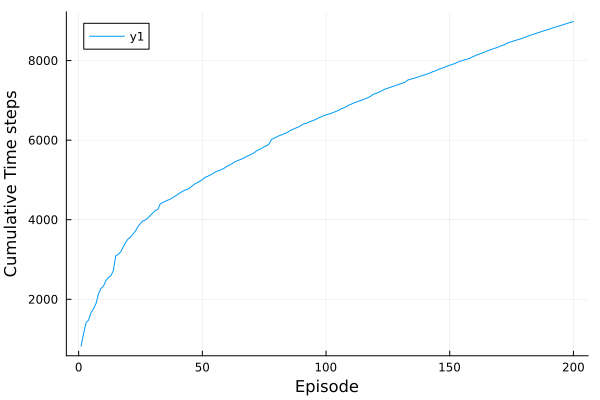

In [ ]:
# action A: up, down ,left, right
# policy π: epsilon - greedy
# upward wind - north bias vector [0 0 0 1 1 1 2 2 1 0] 
wind = [0 0 0 1 1 1 2 2 1 0]

# build valid state actions
sa = Dict()
for r = 1:max_row
    for c = 1:max_col
        valid_actions = []
        # left 
        if 1 <= c-1
            push!(valid_actions, (r,c-1))
        end
        # right 
        if c+1 <= max_col
            push!(valid_actions, (r,c+1))
        end
        # up
        if 1 <= r-1 
            push!(valid_actions, (r-1,c))
        end
        # down
        if r+1 <= max_row 
            push!(valid_actions, (r+1,c))
        end
        sa[(r,c)] = valid_actions

    end
end

# Initialise Q(s,a) = 0 for all s, a
Q = Dict()
for k = keys(sa)
    for v = 1:length(sa[k])
        Q[(k,sa[k][v])] = 0.0
    end
end

# epsilon greedy function
function epsilon_greedy(state, state_action, Q, epsilon)
    greedy_action = nothing
    greedy_action_value = 0.0

    # With probability epsilon pick a random action, with probability 1-epsilon take greedy action
    d = Bernoulli(epsilon)
    sample = rand(d, 1)

    if sample == Bool[1] 
        # Random action
        greedy_action = rand(state_action[state])

    else
        # Greedy action by picking action with maximum Q values
        for action in state_action[state]
            if greedy_action == nothing
                greedy_action = action
                greedy_action_value = Q[state, action] 
            else
                if Q[state, action] > greedy_action_value
                    greedy_action = action
                    greedy_action_value = Q[state, action]
                end 
            end
        end
    end

    return greedy_action
end

step_data = []
step_data2 = []
steps2 = 0

for episode = 1:200
    # Initialise state s, reward
    s = start
    r = 0
    steps = 0
    # Choose action for state with policy π
    a = epsilon_greedy(s, sa, Q, 0.1)

    while true
        # take action a, observe reward r, next state s'
        s_next = (max(1, a[1] - wind[a[2]]), a[2] )   # max op covers hitting north wall case, wind bias added
        r = reward[s...]

        # choose a' from s' with policy π
        a_next = epsilon_greedy(s_next, sa, Q, 0.1)
        
        # update Q
        Q[s,a] = Q[s,a] + alpha * (r + gamma * (Q[s_next,a_next] - Q[s,a]) )

        # update action and state
        s = s_next
        a = a_next

        steps += 1
        steps2 += 1
        if s == goal
            #println(steps)
            push!(step_data, steps)
            push!(step_data2, steps2)
            #println(Q)
            break
        end
        #print(s,"->")
    end
end

println("Min steps found: ", minimum(step_data))
display(plot(step_data, xlabel = "Episode", ylabel = "No. of steps"))
display(plot(step_data2, xlabel = "Episode", ylabel = "Cumulative Time steps"))

In [ ]:
travelled_path = [start]

# Initialise state s, reward
s = start
steps = 0
# Choose action for state with policy π
a = epsilon_greedy(s, sa, Q, 0)  # set epsilon to 0 (greedy action)!!

while true
    # take action a, observe reward r, next state s'
    s_next = (max(1, a[1] - wind[a[2]]), a[2] )   # max op covers hitting north wall case, wind bias added

    # choose a' from s' with policy π
    a_next = epsilon_greedy(s_next, sa, Q, 0)   # set epsilon to 0 (greedy action)!!

    # update action and state
    s = s_next
    a = a_next

    push!(travelled_path, s) 
    steps += 1
    if s == goal
        println(steps)
        break
    end
    
end

gridplot_anim = zeros(max_row, max_col) 
windy_anim = @animate for path in travelled_path
    gridplot_anim[path...] = 1
    (heatmap(gridplot_anim, yflip=true, color=:blues))
end
gif(windy_anim, "windy_gridworld.gif", fps = 5) 


## Q-learning: Off-policy TD control

### Cliff walking

In [1]:
using Random, Distributions, Plots
Random.seed!(123)

alpha = 0.5
gamma = 1
max_row = 4   # max grid rows
max_col = 12  # max grid columns
start = (4,1) # start position
goal = (4,12)  # goal position
# set all positions to -1 reward except goal 
reward = -1 * ones(max_row, max_col)  
reward[goal...] = 0 # set goal reward to 0
reward[4,2:11] .= -100 # set cliff reward to -100
reward

4×12 Matrix{Float64}:
 -1.0    -1.0    -1.0    -1.0    -1.0  …    -1.0    -1.0    -1.0  -1.0
 -1.0    -1.0    -1.0    -1.0    -1.0       -1.0    -1.0    -1.0  -1.0
 -1.0    -1.0    -1.0    -1.0    -1.0       -1.0    -1.0    -1.0  -1.0
 -1.0  -100.0  -100.0  -100.0  -100.0     -100.0  -100.0  -100.0   0.0

### Q-learning version of cliff walking

Min steps found: 13


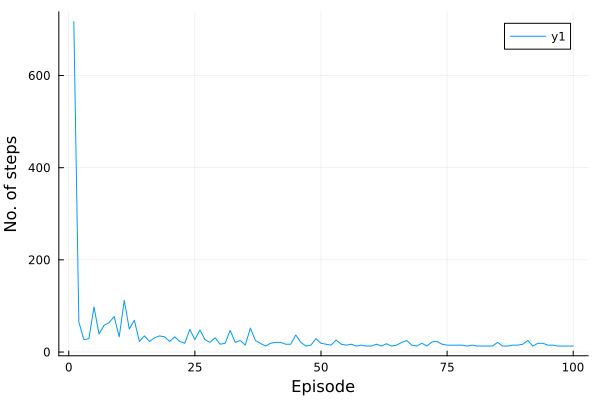

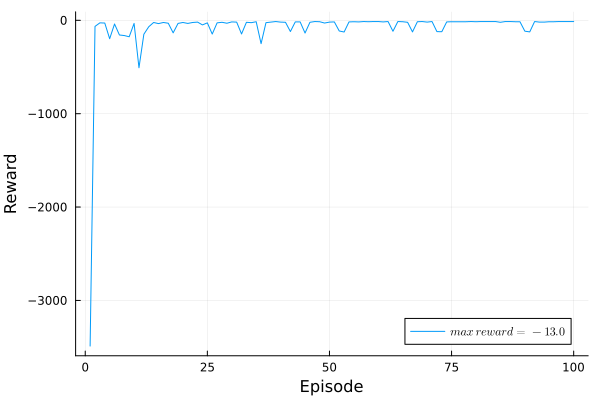

In [ ]:
# Q-learning for cliff walking
# action A: up, down, left, right
# policy π: epsilon - greedy

# build valid state actions
function build_state_action(max_row, max_col)
    sa = Dict()
    for r = 1:max_row
        for c = 1:max_col
            valid_actions = []
            # left 
            if 1 <= c-1
                push!(valid_actions, (r,c-1))
            end
            # right 
            if c+1 <= max_col
                push!(valid_actions, (r,c+1))
            end
            # up
            if 1 <= r-1 
                push!(valid_actions, (r-1,c))
            end
            # down
            if r+1 <= max_row 
                push!(valid_actions, (r+1,c))
            end
            sa[(r,c)] = valid_actions

        end
    end

    # cliff case 
    for i = 2:max_col-1
        sa[(4,i)] = Any[(4,1)]
    end
    return sa
end

sa = build_state_action(max_row, max_col)

# Initialise Q(s,a) = 0 for all s, a
Q = Dict()
for k = keys(sa)
    for v = 1:length(sa[k])
        Q[(k,sa[k][v])] = 0.0
    end
end

# epsilon greedy function
function epsilon_greedy(state, state_action, Q, epsilon)
    greedy_action = nothing
    greedy_action_value = 0.0

    # With probability epsilon pick a random action, with probability 1-epsilon take greedy action
    d = Bernoulli(epsilon)
    sample = rand(d, 1)

    if sample == Bool[1] 
        # Random action
        greedy_action = rand(state_action[state])

    else
        # Greedy action by picking action with maximum Q values
        for action in state_action[state]
            if greedy_action == nothing
                greedy_action = action
                greedy_action_value = Q[state, action] 
            else
                if Q[state, action] > greedy_action_value
                    greedy_action = action
                    greedy_action_value = Q[state, action]
                end 
            end
        end
    end

    return greedy_action
end

step_data = []
av_reward = []


for episode = 1:100
    # Initialise state s, reward
    s = start
    r = 0
    steps = 0
    reward_counter = 0
    while true
        # Choose action for state with policy π
        a = epsilon_greedy(s, sa, Q, 0.1)
        # take action a, observe reward r, next state s'
        s_next = a
        r = reward[s...]

        # choose a' from s' which returns max Q value 
        a_next = epsilon_greedy(s_next, sa, Q, 0)   # epsilon = 0 is greedy action by taking action with max Q
        
        # update Q
        Q[s,a] = Q[s,a] + alpha * (r + gamma * (Q[s_next,a_next] - Q[s,a]) )

        # update state. No update to action!
        s = s_next

        steps += 1
        reward_counter += r
        if s == goal
            #println(steps)
            push!(step_data, steps)
            push!(av_reward, reward_counter)
            #println(Q)
            break
        end
        #print(s,"->")
    end
end
max_reward = maximum(av_reward)
println("Min steps found: ", minimum(step_data))
display(plot(step_data, xlabel = "Episode", ylabel = "No. of steps"))
display(plot(av_reward, xlabel = "Episode", ylabel = "Reward", label = "\$max\\: reward=$max_reward\$"))



13


[ Info: Saved animation to /Users/nicholasting/Desktop/github_projects/attention/cliff_q_learning.gif


Plots.AnimatedGif("/Users/nicholasting/Desktop/github_projects/attention/cliff_q_learning.gif")
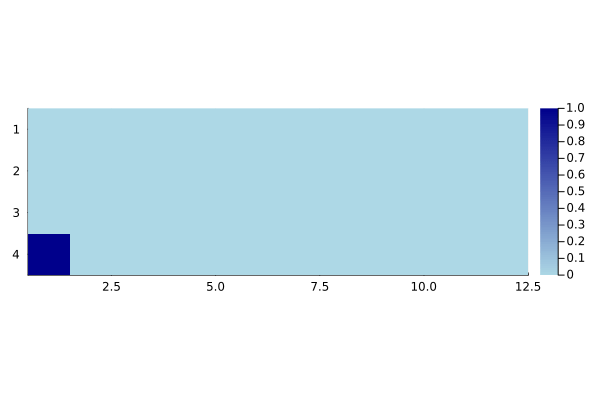

In [10]:
travelled_path = [start]

# Initialise state s, reward
s = start
steps = 0

while true
    # Choose action for state with policy π
    a = epsilon_greedy(s, sa, Q, 0)  # set epsilon to 0 (greedy action)!!
    # take action a, observe reward r, next state s'
    s_next = a

    # choose a' from s' which returns max Q value 
    a_next = epsilon_greedy(s_next, sa, Q, 0)   # set epsilon to 0 (greedy action)!!

    # update action and state
    s = s_next

    push!(travelled_path, s) 
    steps += 1
    if s == goal
        println(steps)
        break
    end
    
end

gridplot_anim = zeros(max_row, max_col) 
cliff_qlearning_anim = @animate for path in travelled_path
    gridplot_anim[path...] = 1
    (heatmap(gridplot_anim, yflip=true, color=:blues, aspect_ratio=:equal, ylimits=(0.5,4.5)))
end
gif(cliff_qlearning_anim, "cliff_q_learning.gif", fps = 5) 

### Sarsa version of cliff walking

Min steps found: 17


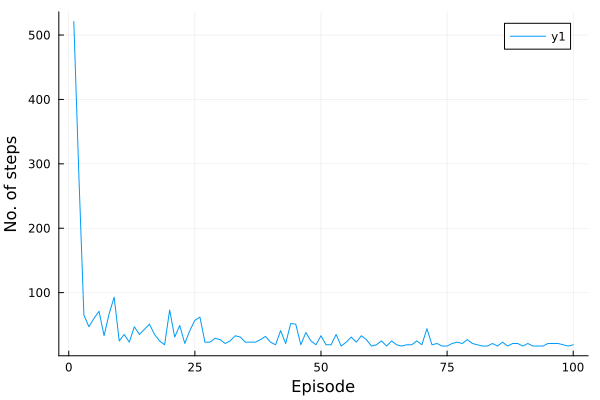

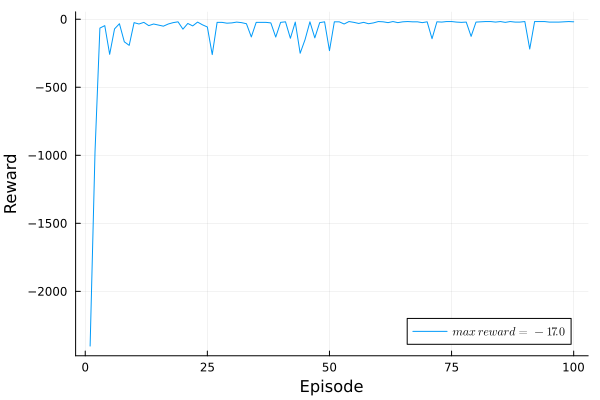

In [11]:
# Sarsa version of cliff walking

sa = build_state_action(max_row, max_col)

# Initialise Q(s,a) = 0 for all s, a
Q = Dict()
for k = keys(sa)
    for v = 1:length(sa[k])
        Q[(k,sa[k][v])] = 0.0
    end
end

step_data = []
av_reward = []

for episode = 1:100
    # Initialise state s, reward
    s = start
    r = 0
    steps = 0
    reward_counter = 0
    # Choose action for state with policy π
    a = epsilon_greedy(s, sa, Q, 0.1)
    while true
        # take action a, observe reward r, next state s'
        s_next = a
        r = reward[s...]

        # choose a' from s' with policy π
        a_next = epsilon_greedy(s_next, sa, Q, 0.1)
        
        # update Q
        Q[s,a] = Q[s,a] + alpha * (r + gamma * (Q[s_next,a_next] - Q[s,a]) )

        # update action and state
        s = s_next
        a = a_next

        steps += 1
        reward_counter += r
        if s == goal
            #println(steps)
            push!(step_data, steps)
            push!(av_reward, reward_counter)
            #println(Q)
            break
        end
        #print(s,"->")
    end
end
max_reward = maximum(av_reward)
println("Min steps found: ", minimum(step_data))
display(plot(step_data, xlabel = "Episode", ylabel = "No. of steps"))
display(plot(av_reward, xlabel = "Episode", ylabel = "Reward", label = "\$max\\: reward=$max_reward\$"))



17


[ Info: Saved animation to /Users/nicholasting/Desktop/github_projects/attention/cliff_sarsa.gif


Plots.AnimatedGif("/Users/nicholasting/Desktop/github_projects/attention/cliff_sarsa.gif")
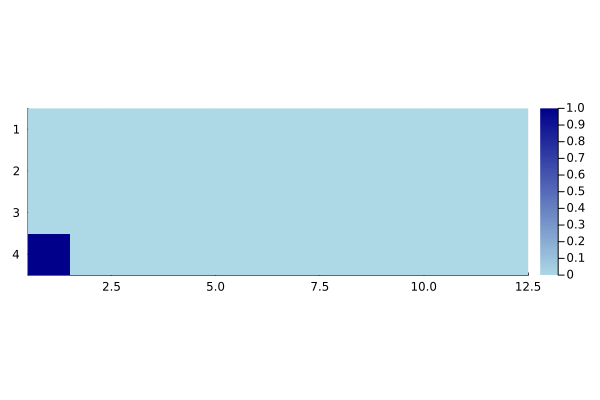

In [12]:
travelled_path = [start]

# Initialise state s, reward
s = start
steps = 0
# Choose action for state with policy π
a = epsilon_greedy(s, sa, Q, 0)  # set epsilon to 0 (greedy action)!!

while true
    # take action a, observe reward r, next state s'
    s_next = a

    # choose a' from s' with policy π
    a_next = epsilon_greedy(s_next, sa, Q, 0)   # set epsilon to 0 (greedy action)!!

    # update action and state
    s = s_next
    a = a_next

    push!(travelled_path, s) 
    steps += 1
    if s == goal
        println(steps)
        break
    end
    
end

gridplot_anim = zeros(max_row, max_col) 
cliff_sarsa_anim = @animate for path in travelled_path
    gridplot_anim[path...] = 1
    (heatmap(gridplot_anim, yflip=true, color=:blues, aspect_ratio=:equal, ylimits=(0.5,4.5)))
end
gif(cliff_sarsa_anim, "cliff_sarsa.gif", fps = 5) 
